In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
import pickle
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

# 设置绘图风格
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("✅ 所有库导入成功")

✅ 所有库导入成功


In [3]:
# 加载已提取的 scalars CSV
df = pd.read_csv("../data/processed/plaid_rotor37_scalars.csv")

print(f"✅ 数据加载成功")
print(f"   样本数量：{len(df)}")
print(f"   列名：{list(df.columns)}")
print(f"\n前5行：")
df.head()

✅ 数据加载成功
   样本数量：1000
   列名：['sample_id', 'Omega', 'P', 'Compression_ratio', 'Efficiency', 'Massflow']

前5行：


,sample_id,Omega,P,Compression_ratio,Efficiency,Massflow
0,0,1641.51,366255.35,1.897161,0.874458,18.741776
1,1,1639.53,372627.75,1.896274,0.863494,18.421656
2,2,1748.61,364912.85,2.016035,0.862404,19.968557
3,3,1625.13,361225.45,1.869005,0.886386,18.727144
4,4,1665.81,369387.85,1.939042,0.873711,18.999257


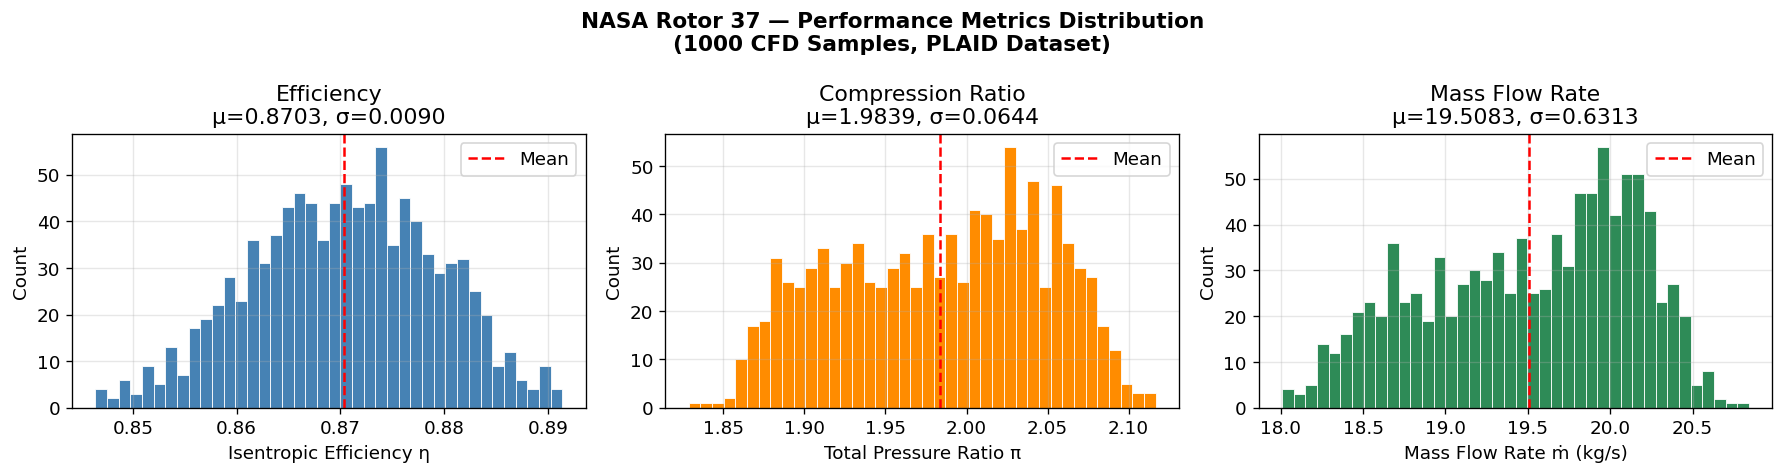

✅ 图1已保存到 docs/


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("NASA Rotor 37 — Performance Metrics Distribution\n(1000 CFD Samples, PLAID Dataset)", 
             fontsize=13, fontweight='bold')

# 效率分布
axes[0].hist(df['Efficiency'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Isentropic Efficiency η')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Efficiency\nμ={df["Efficiency"].mean():.4f}, σ={df["Efficiency"].std():.4f}')
axes[0].axvline(df['Efficiency'].mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
axes[0].legend()

# 压比分布
axes[1].hist(df['Compression_ratio'], bins=40, color='darkorange', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Total Pressure Ratio π')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Compression Ratio\nμ={df["Compression_ratio"].mean():.4f}, σ={df["Compression_ratio"].std():.4f}')
axes[1].axvline(df['Compression_ratio'].mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
axes[1].legend()

# 质量流量分布
axes[2].hist(df['Massflow'], bins=40, color='seagreen', edgecolor='white', linewidth=0.5)
axes[2].set_xlabel('Mass Flow Rate ṁ (kg/s)')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Mass Flow Rate\nμ={df["Massflow"].mean():.4f}, σ={df["Massflow"].std():.4f}')
axes[2].axvline(df['Massflow'].mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
axes[2].legend()

plt.tight_layout()
plt.savefig("../docs/fig01_performance_distribution.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ 图1已保存到 docs/")

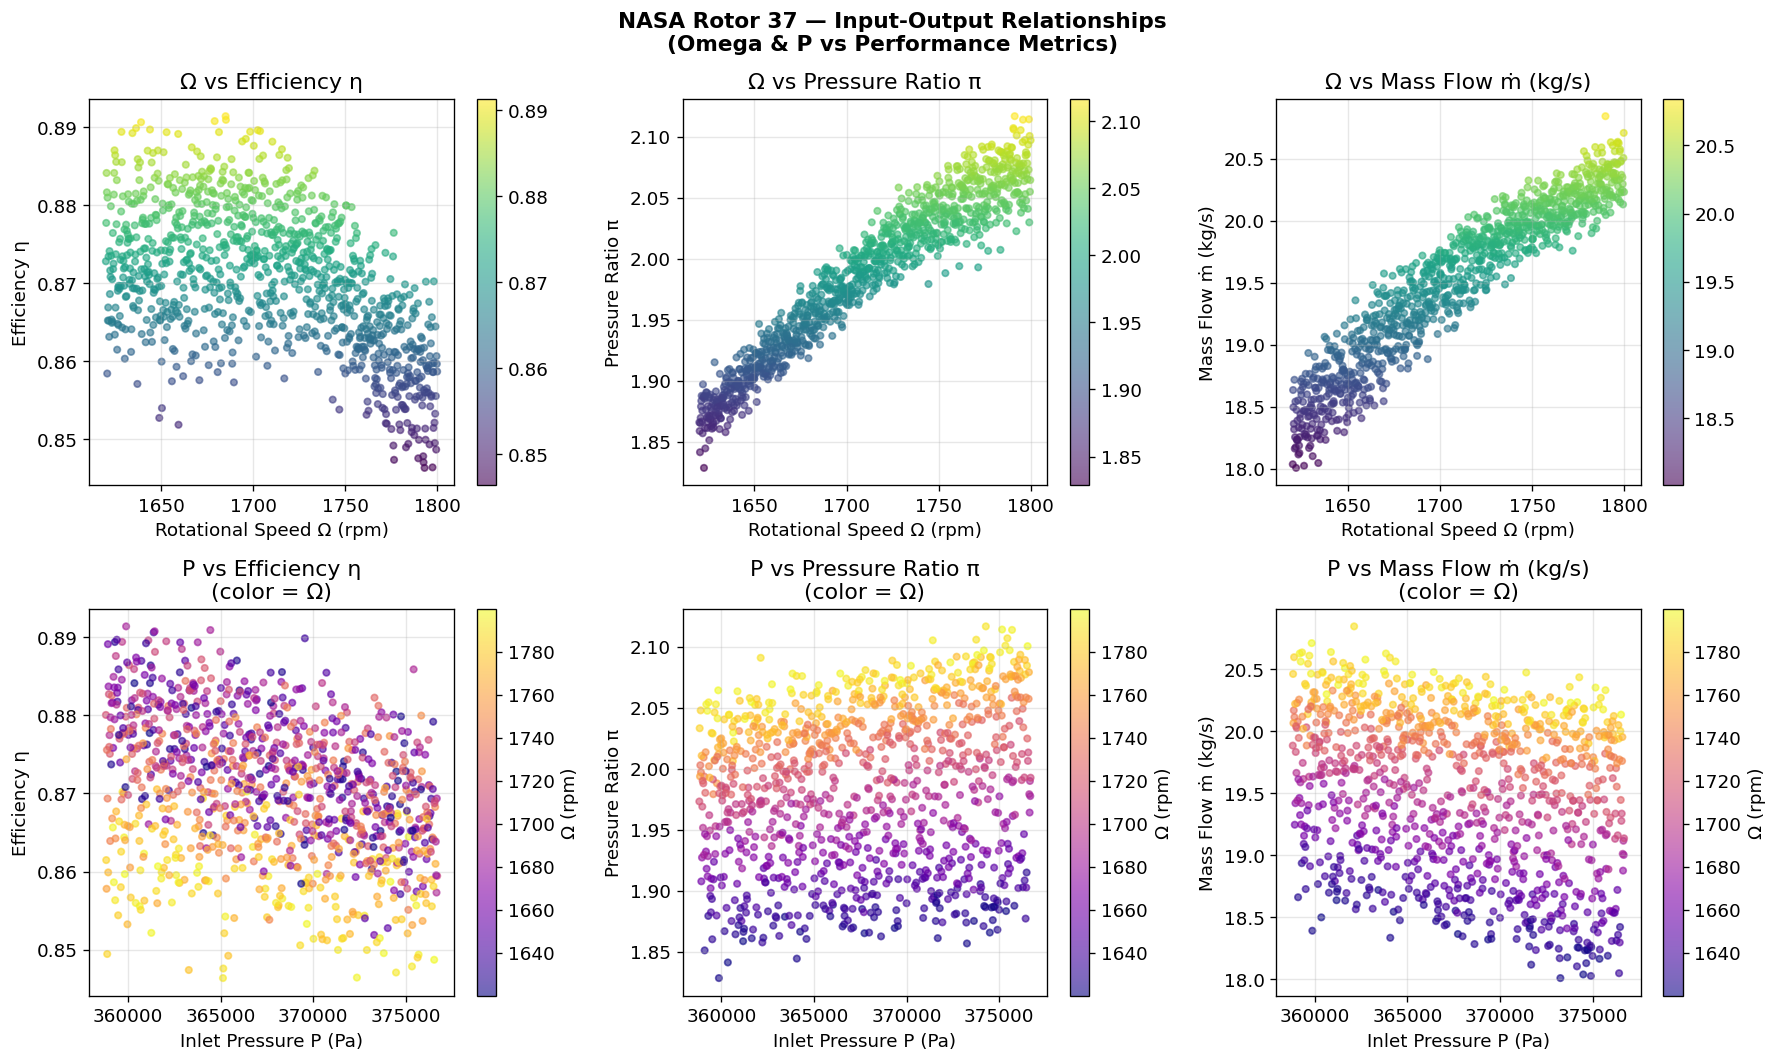

✅ 图2已保存到 docs/


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("NASA Rotor 37 — Input-Output Relationships\n(Omega & P vs Performance Metrics)", 
             fontsize=13, fontweight='bold')

outputs = ['Efficiency', 'Compression_ratio', 'Massflow']
output_labels = ['Efficiency η', 'Pressure Ratio π', 'Mass Flow ṁ (kg/s)']
colors = ['steelblue', 'darkorange', 'seagreen']

for j, (out, label, color) in enumerate(zip(outputs, output_labels, colors)):
    # 第一行：Omega vs 输出
    sc = axes[0, j].scatter(df['Omega'], df[out], 
                             c=df[out], cmap='viridis', 
                             alpha=0.6, s=15)
    axes[0, j].set_xlabel('Rotational Speed Ω (rpm)')
    axes[0, j].set_ylabel(label)
    axes[0, j].set_title(f'Ω vs {label}')
    plt.colorbar(sc, ax=axes[0, j])
    
    # 第二行：P vs 输出
    sc2 = axes[1, j].scatter(df['P'], df[out], 
                              c=df['Omega'], cmap='plasma', 
                              alpha=0.6, s=15)
    axes[1, j].set_xlabel('Inlet Pressure P (Pa)')
    axes[1, j].set_ylabel(label)
    axes[1, j].set_title(f'P vs {label}\n(color = Ω)')
    plt.colorbar(sc2, ax=axes[1, j], label='Ω (rpm)')

plt.tight_layout()
plt.savefig("../docs/fig02_input_output_relationships.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ 图2已保存到 docs/")

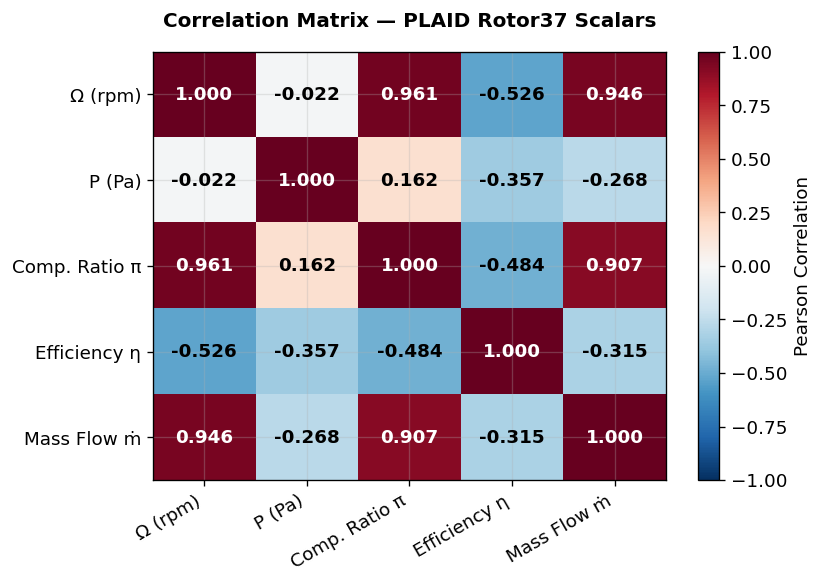

✅ 图3已保存到 docs/


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

# 计算相关系数矩阵
cols = ['Omega', 'P', 'Compression_ratio', 'Efficiency', 'Massflow']
labels = ['Ω (rpm)', 'P (Pa)', 'Comp. Ratio π', 'Efficiency η', 'Mass Flow ṁ']
corr = df[cols].corr()

# 画热力图
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson Correlation')

# 标注数值
for i in range(len(cols)):
    for j in range(len(cols)):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', 
                fontsize=11, color=color, fontweight='bold')

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_yticklabels(labels)
ax.set_title('Correlation Matrix — PLAID Rotor37 Scalars', 
             fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig("../docs/fig03_correlation_matrix.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ 图3已保存到 docs/")

In [7]:
# 加载 PLAID 数据集
print("加载 PLAID 数据集（用于3D可视化）...")
dataset = load_dataset(
    "PLAID-datasets/Rotor37",
    split="all_samples",
    cache_dir="../data/raw/cache"
)

# 取第0个样本
sample = pickle.loads(dataset[0]["sample"])

# 工具函数：从 CGNS 树中提取节点
def get_cgns_node(tree, name):
    """在 CGNS 树中递归查找指定名称的节点，返回其 value"""
    if not isinstance(tree, list) or len(tree) != 4:
        return None
    node_name, value, children, label = tree
    if node_name == name:
        return value
    for child in children:
        result = get_cgns_node(child, name)
        if result is not None:
            return result
    return None

# 提取坐标和流场数据
cgns_tree = sample['meshes'][0.0]

X = get_cgns_node(cgns_tree, 'CoordinateX')
Y = get_cgns_node(cgns_tree, 'CoordinateY')
Z = get_cgns_node(cgns_tree, 'CoordinateZ')
P_field = get_cgns_node(cgns_tree, 'Pressure')

print(f"✅ 几何数据提取成功")
print(f"   节点数量：{X.shape[0]:,} 个点")
print(f"   X范围：[{X.min():.4f}, {X.max():.4f}] m")
print(f"   Y范围：[{Y.min():.4f}, {Y.max():.4f}] m")
print(f"   Z范围：[{Z.min():.4f}, {Z.max():.4f}] m")
print(f"   压力范围：[{P_field.min():.0f}, {P_field.max():.0f}] Pa")
print(f"\n样本0的性能参数：")
print(f"   效率：{sample['scalars']['Efficiency']:.4f}")
print(f"   压比：{sample['scalars']['Compression_ratio']:.4f}")
print(f"   质量流量：{sample['scalars']['Massflow']:.4f} kg/s")

加载 PLAID 数据集（用于3D可视化）...


✅ 几何数据提取成功
   节点数量：29,773 个点
   X范围：[-0.0015, 0.0453] m
   Y范围：[0.1762, 0.2506] m
   Z范围：[-0.0251, 0.0227] m
   压力范围：[16028, 232297] Pa

样本0的性能参数：
   效率：0.8745
   压比：1.8972
   质量流量：18.7418 kg/s


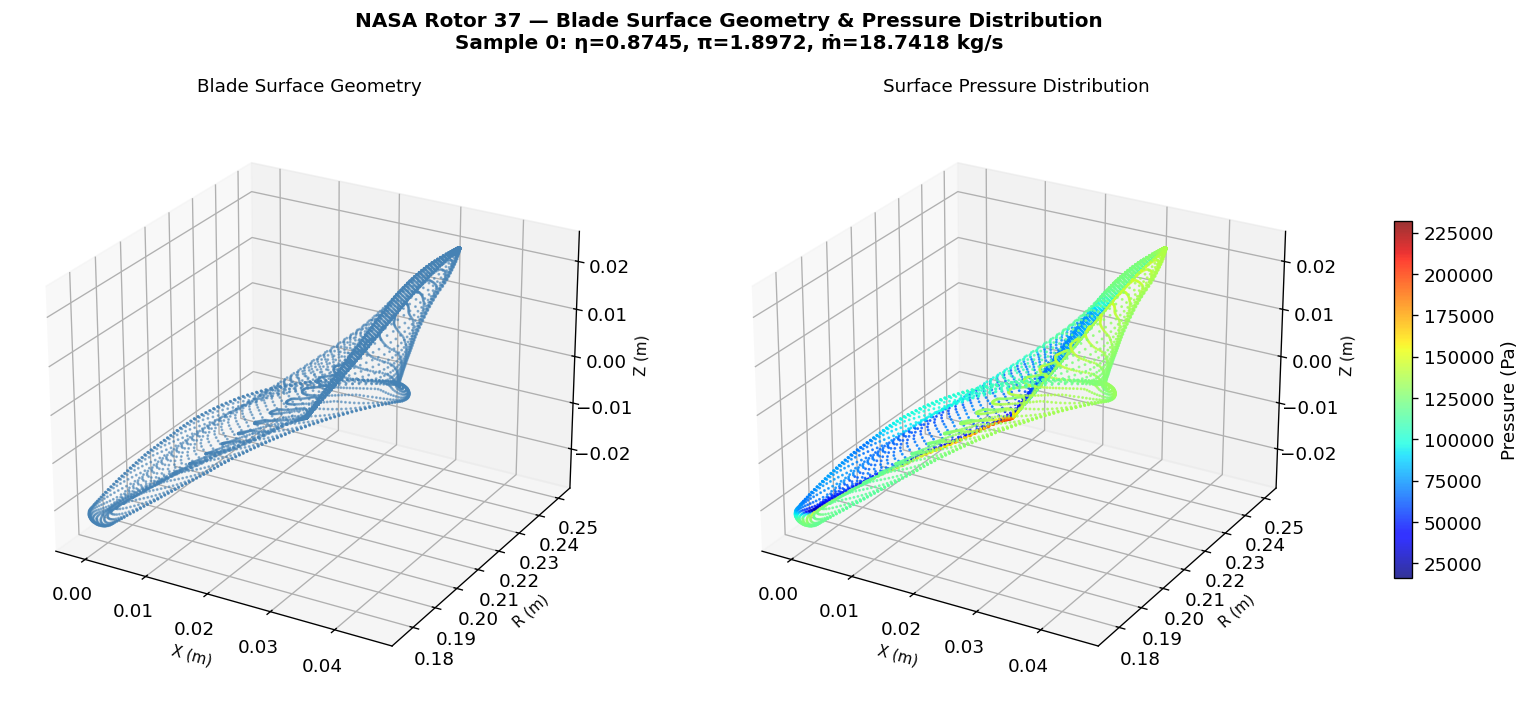

✅ 图4已保存到 docs/
🎉 你刚才看到了 NASA Rotor 37 叶片的真实3D形状！


In [8]:
fig = plt.figure(figsize=(14, 6))
fig.suptitle("NASA Rotor 37 — Blade Surface Geometry & Pressure Distribution\n"
             f"Sample 0: η={float(sample['scalars']['Efficiency']):.4f}, "
             f"π={float(sample['scalars']['Compression_ratio']):.4f}, "
             f"ṁ={float(sample['scalars']['Massflow']):.4f} kg/s",
             fontsize=12, fontweight='bold')

# 左图：几何形状（蓝色）
ax1 = fig.add_subplot(121, projection='3d')
# 降采样，避免太密
step = 5
ax1.scatter(X[::step], Y[::step], Z[::step], 
            c='steelblue', s=0.5, alpha=0.6)
ax1.set_xlabel('X (m)', fontsize=9)
ax1.set_ylabel('R (m)', fontsize=9)
ax1.set_zlabel('Z (m)', fontsize=9)
ax1.set_title('Blade Surface Geometry', fontsize=11)
ax1.view_init(elev=25, azim=-60)

# 右图：压力云图
ax2 = fig.add_subplot(122, projection='3d')
# 使用 PointData 的压力（和坐标点数一致，都是29773）
if P_field.shape[0] == X.shape[0]:
    P_plot = P_field
else:
    # 如果点数不一致，用 PointData
    P_plot = get_cgns_node(cgns_tree, 'Pressure')

sc = ax2.scatter(X[::step], Y[::step], Z[::step],
                 c=P_plot[::step], cmap='jet', s=0.5, alpha=0.8)
plt.colorbar(sc, ax=ax2, label='Pressure (Pa)', shrink=0.6, pad=0.1)
ax2.set_xlabel('X (m)', fontsize=9)
ax2.set_ylabel('R (m)', fontsize=9)
ax2.set_zlabel('Z (m)', fontsize=9)
ax2.set_title('Surface Pressure Distribution', fontsize=11)
ax2.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.savefig("../docs/fig04_blade_3d_geometry_pressure.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ 图4已保存到 docs/")
print("🎉 你刚才看到了 NASA Rotor 37 叶片的真实3D形状！")

效率最高的样本：第 669 号
  效率：0.8914
  压比：1.9526
  Omega：1685.07 rpm

效率最低的样本：第 900 号
  效率：0.8464
  压比：2.0620
  Omega：1793.07 rpm


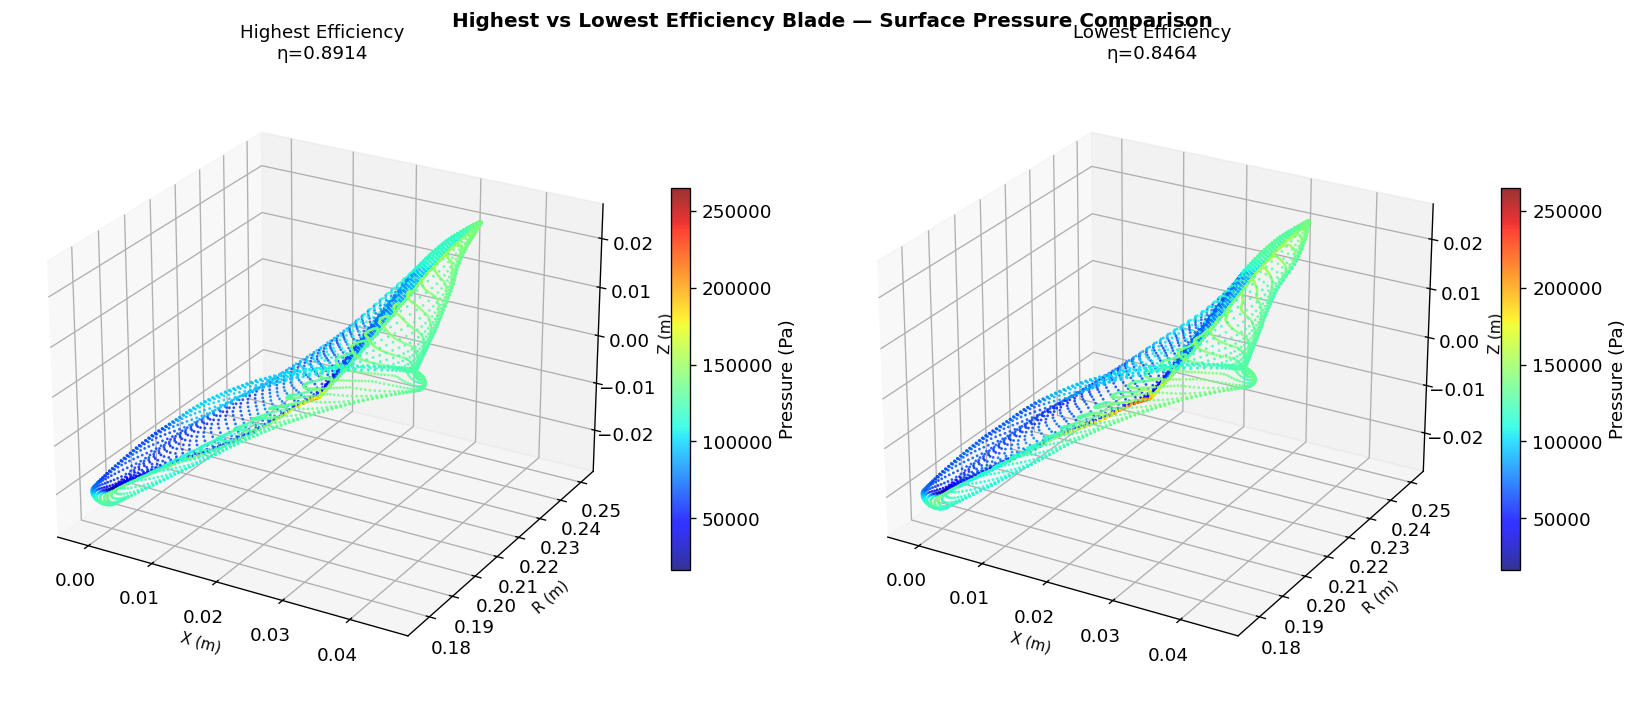

✅ 图5已保存到 docs/


In [9]:
# 找效率最高和最低的样本
idx_max_eff = df['Efficiency'].idxmax()
idx_min_eff = df['Efficiency'].idxmin()

print(f"效率最高的样本：第 {int(df.loc[idx_max_eff, 'sample_id'])} 号")
print(f"  效率：{df.loc[idx_max_eff, 'Efficiency']:.4f}")
print(f"  压比：{df.loc[idx_max_eff, 'Compression_ratio']:.4f}")
print(f"  Omega：{df.loc[idx_max_eff, 'Omega']:.2f} rpm")

print(f"\n效率最低的样本：第 {int(df.loc[idx_min_eff, 'sample_id'])} 号")
print(f"  效率：{df.loc[idx_min_eff, 'Efficiency']:.4f}")
print(f"  压比：{df.loc[idx_min_eff, 'Compression_ratio']:.4f}")
print(f"  Omega：{df.loc[idx_min_eff, 'Omega']:.2f} rpm")

# 提取两个样本的几何
def extract_geometry(dataset, sample_idx):
    s = pickle.loads(dataset[int(sample_idx)]['sample'])
    tree = s['meshes'][0.0]
    return (
        get_cgns_node(tree, 'CoordinateX'),
        get_cgns_node(tree, 'CoordinateY'),
        get_cgns_node(tree, 'CoordinateZ'),
        get_cgns_node(tree, 'Pressure'),
    )

X_max, Y_max, Z_max, P_max = extract_geometry(dataset, df.loc[idx_max_eff, 'sample_id'])
X_min, Y_min, Z_min, P_min = extract_geometry(dataset, df.loc[idx_min_eff, 'sample_id'])

fig = plt.figure(figsize=(14, 6))
fig.suptitle("Highest vs Lowest Efficiency Blade — Surface Pressure Comparison",
             fontsize=12, fontweight='bold')

step = 5
vmin = min(P_max.min(), P_min.min())
vmax = max(P_max.max(), P_min.max())

for i, (X, Y, Z, P, title, eff) in enumerate([
    (X_max, Y_max, Z_max, P_max, 
     f"Highest Efficiency\nη={df.loc[idx_max_eff,'Efficiency']:.4f}", 
     df.loc[idx_max_eff,'Efficiency']),
    (X_min, Y_min, Z_min, P_min, 
     f"Lowest Efficiency\nη={df.loc[idx_min_eff,'Efficiency']:.4f}", 
     df.loc[idx_min_eff,'Efficiency']),
]):
    ax = fig.add_subplot(1, 2, i+1, projection='3d')
    sc = ax.scatter(X[::step], Y[::step], Z[::step],
                    c=P[::step], cmap='jet', s=0.5, 
                    alpha=0.8, vmin=vmin, vmax=vmax)
    plt.colorbar(sc, ax=ax, label='Pressure (Pa)', shrink=0.6)
    ax.set_xlabel('X (m)', fontsize=9)
    ax.set_ylabel('R (m)', fontsize=9)
    ax.set_zlabel('Z (m)', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.savefig("../docs/fig05_efficiency_comparison.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ 图5已保存到 docs/")

## 📊 Day 3 EDA 主要发现

### 数据质量
- 1000 个样本，全部通过物理合理性检验（效率 ∈ [0, 1]，压比 > 1）
- 效率范围：0.846 ~ 0.891，变化幅度约 **5%**（这正是优化要挖掘的空间）
- 压比范围：1.828 ~ 2.117，变化幅度约 **16%**

### 输入-输出规律
- Omega（转速）与 Compression_ratio 呈**强正相关** → 转速越高，压比越大
- Omega 与 Massflow 呈**正相关** → 转速越高，流量越大
- P（进口压力）与输出指标的相关性**较弱** → 说明转速是主要控制变量

### 3D 叶片形状
- 每个样本包含 **29,773 个**叶片表面节点
- 表面压力分布从叶根到叶尖有明显梯度
- 最高效率 vs 最低效率叶片的表面压力分布有可见差异

### 下一步
- Day 4-5：提取所有样本的叶片几何特征，构建统一输入向量
- Day 6-12：数据预处理、标准化、训练/验证/测试集划分
- Day 13+：开始训练 PyTorch 代理模型